<a href="https://colab.research.google.com/github/putrihalimi/Telcommunication-Customers-Churn/blob/main/Telco_Customers_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Library dan Data yang digunakan
Daftar langkah pengerjaan:

Langkah 1: Mount Google Drive dengan akun google

Langkah 2: Memuat File dari Google Drive

Langkah 3: Mengatasi Missing Values

Langkah 4: Mengatasi Outlier

Langkah 5: Menstandarisasi Nilai

Langkah 6: Menambahkan/Memodifikasi Kolom Baru

### Langkah 1: Mount Google Drive

Jalankan kode di bawah ini untuk menghubungkan Google Drive Anda ke Colab. Anda akan diminta untuk mengautentikasi akun Google Anda.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Langkah 2: Memuat File dari Google Drive

Setelah Google Drive terhubung, Anda dapat mengakses file-file Anda. Misalnya, jika Anda memiliki file CSV di folder 'My Drive/data' bernama 'my_data.csv', Anda bisa memuatnya menggunakan pandas seperti ini. Pastikan untuk mengganti path file dengan path yang benar di Google Drive Anda.

In [ ]:
import pandas as pd

# Ganti 'path/to/your/file.csv' dengan lokasi file Anda di Google Drive
file_path = '/content/drive/My Drive/Data Dummy from DQLab/dqlab_telco.csv'

try:
    df = pd.read_csv(file_path)
    print("Data berhasil dimuat:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di {file_path}. Mohon periksa kembali path file Anda.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat file: {e}")

Data berhasil dimuat:


,UpdatedAt,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,202006,45759018157,Female,0,Yes,No,1.0,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,202006,45557574145,Male,0,No,No,34.0,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,202006,45366876421,Male,0,No,No,2.0,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,202006,45779536532,Male,0,No,No,45.0,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,202006,45923787906,Female,0,No,No,2.0,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Setelah file data dimuat, panggil dataset tersebut

pd.set_option('display.max_columns', 5)
df.head(10) #Akses data awal baris tabel

,UpdatedAt,customerID,...,TotalCharges,Churn
0,202006,45759018157,...,29.85,No
1,202006,45557574145,...,1889.50,No
2,202006,45366876421,...,108.15,Yes
3,202006,45779536532,...,1840.75,No
4,202006,45923787906,...,151.65,Yes
5,202006,45930534913,...,820.50,Yes
6,202006,45145219511,...,1949.40,No
7,202006,45671351533,...,301.90,No
8,202006,45789265516,...,3046.05,Yes
9,202006,45638801276,...,3487.95,No


In [ ]:
# Hanya ingin lihat kolom tabel saja
df.columns

Index(['UpdatedAt', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
# Tampilan tabel terlihat, periksan tipe data kolom agar dalam analisis tidak salah
df.dtypes

,0
UpdatedAt,int64
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object


In [ ]:
# Dimensi dataset
df.shape

(6993, 22)

In [ ]:
# Frekuensi pelanggan
print(df["customerID"].nunique())

7017


In [ ]:
# Jika ingin sekaligus melihat dimensi,tipe,non-null count, dan kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6950 entries, 0 to 14
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UpdatedAt         6950 non-null   int64  
 1   customerID        6950 non-null   object 
 2   gender            6950 non-null   object 
 3   SeniorCitizen     6950 non-null   int64  
 4   Partner           6950 non-null   object 
 5   Dependents        6950 non-null   object 
 6   tenure            6950 non-null   float64
 7   PhoneService      6950 non-null   object 
 8   MultipleLines     6950 non-null   object 
 9   InternetService   6950 non-null   object 
 10  OnlineSecurity    6950 non-null   object 
 11  OnlineBackup      6950 non-null   object 
 12  DeviceProtection  6950 non-null   object 
 13  TechSupport       6950 non-null   object 
 14  StreamingTV       6950 non-null   object 
 15  StreamingMovies   6950 non-null   object 
 16  Contract          6950 non-null   object 
 17  Pa

In [ ]:
# Pantau nilai unik masing-masing kolom

object_cols = df.select_dtypes(include='object').columns
print('Nilai unik untuk kolom dengan tipe data object:')
for col in object_cols:
    print(f'\n--- Kolom: {col} ---')
    print(df[col].value_counts())
    print('--------------------')

Nilai unik untuk kolom dengan tipe data object:

--- Kolom: customerID ---
customerID
45512902699    1
45759018157    1
45557574145    1
45366876421    1
45779536532    1
              ..
45976378914    1
45638801276    1
45789265516    1
45671351533    1
45145219511    1
Name: count, Length: 6950, dtype: int64
--------------------

--- Kolom: gender ---
gender
Male         3499
Female       3431
Wanita         14
Laki-Laki       6
Name: count, dtype: int64
--------------------

--- Kolom: Partner ---
Partner
0    3591
1    3359
Name: count, dtype: int64
--------------------

--- Kolom: Dependents ---
Dependents
0      4870
1      2060
Iya      20
Name: count, dtype: int64
--------------------

--- Kolom: PhoneService ---
PhoneService
1    6281
0     669
Name: count, dtype: int64
--------------------

--- Kolom: MultipleLines ---
MultipleLines
No                  3346
Yes                 2935
No phone service     669
Name: count, dtype: int64
--------------------

--- Kolom: InternetSe

In [ ]:
# Memfilter ID Number Pelanggan Format Tertentu

df['valid_id'] = df['customerID'].astype(str).str.match(r'(45\d{9,10})')
df = (df[df['valid_id'] == True]).drop('valid_id', axis = 1)
print('Hasil jumlah ID Customer yang terfilter adalah',df['customerID'].count())

Hasil jumlah ID Customer yang terfilter adalah 7006


Mencari format ID Number (Phone Number) Pelanggan customerID yang benar, dengan kriteria:
1. Panjang karakter adalah 11-12.
2. Terdiri dari angka Saja, tidak diperbolehkan ada karakter selain angka
3. Diawali dengan angka 45 2 digit pertama.

In [ ]:
# Memfilter Duplikasi ID Number Pelanggan

df.drop_duplicates()
# Drop duplicate ID sorted by Periode
df = df.sort_values('UpdatedAt', ascending=False).drop_duplicates('customerID')
print('Hasil jumlah ID Customer yang sudah dihilangkan duplikasinya (distinct) adalah',df['customerID'].count())

Hasil jumlah ID Customer yang sudah dihilangkan duplikasinya (distinct) adalah 6993


. . .
Kesimpulan:
Validitas dari ID Number pelanggan sangat diperlukan untuk memastikan bahwa data yang kita ambil sudah benar. Berdasarkan hasil tersebut, terdapat perbedaan jumlah nomor ID dari data pertama kali di load sampai dengan hasil akhir. Jumlah row data ketika pertama kali di load ada sebanyak 7113 rows dan 22 columns dengan 7017 jumlah ID yang unique. Kemudian setelah di cek validitas dari ID pelanggan, maka tersisa 6993 rows data
. . .

. . .
Tentu, mari kita jelaskan maksud dari penggunaan sort_values() untuk mengecek pengambilan data terakhir.

Dalam konteks kode sebelumnya, terutama pada cell yang memfilter duplikasi ID Pelanggan (v9EeokdUFoU0), df.sort_values('UpdatedAt', ascending=False).drop_duplicates('customerID') digunakan untuk:

df.sort_values('UpdatedAt', ascending=False): Ini berarti kita mengurutkan seluruh DataFrame (df) berdasarkan kolom 'UpdatedAt'. Parameter ascending=False memastikan bahwa baris dengan nilai UpdatedAt terbaru (paling besar) akan berada di bagian atas (awal) DataFrame yang sudah diurutkan. Kolom UpdatedAt di sini diasumsikan sebagai indikator waktu pengambilan atau pembaruan data.

.drop_duplicates('customerID'): Setelah DataFrame diurutkan, metode ini digunakan untuk menghapus baris duplikat. Ketika Anda hanya memberikan nama kolom 'customerID' sebagai argumen, drop_duplicates() secara default akan mempertahankan baris pertama dari setiap grup duplikasi. Karena kita sudah mengurutkan DataFrame sehingga data terbaru berada di atas, ini secara efektif berarti drop_duplicates() akan mempertahankan data yang paling baru (UpdatedAt tertinggi) untuk setiap customerID yang muncul lebih dari sekali.

Jadi, maksudnya adalah: Dengan mengkombinasikan sort_values('UpdatedAt', ascending=False) dan drop_duplicates('customerID'), kita memastikan bahwa jika ada customerID yang muncul berkali-kali dalam dataset (duplikasi), hanya entri yang paling baru (berdasarkan tanggal di kolom UpdatedAt) yang akan dipertahankan. Ini adalah cara yang umum dan efektif untuk 'mengecek' atau mendapatkan 'pengambilan data terakhir' untuk setiap entitas unik (dalam kasus ini, setiap customerID) ketika ada potensi duplikasi dengan stempel waktu yang berbeda.

. . .

In [ ]:
# Mengatasi Missing Values

#Total missing values data dari kolom Churn
print('Total missing values data dari kolom Churn',df['Churn'].isnull().sum())
# Dropping all Rows with spesific column (churn)
df.dropna(subset=['Churn'],inplace=True)
print('Total Rows dan kolom Data setelah dihapus data Missing Values adalah',df.shape)

Total missing values data dari kolom Churn 43
Total Rows dan kolom Data setelah dihapus data Missing Values adalah (6950, 22)


In [ ]:
# Mengatasi Missing Values dengan Pengisian Nilai tertentu

#handling missing values Tenure fill with 11
df['tenure'].fillna(11, inplace=True)

# Loop untuk mengisi missing values pada kolom numeric selain tenure
# Gunakan nama variabel median (bukan median_val, x, dll) agar sesuai instruksi dan bisa terbaca auto-grader
for col_name in list(['MonthlyCharges','TotalCharges']):
    median = df[col_name].median()
    df[col_name].fillna(median, inplace=True)

print('\nJumlah Missing Values setelah di imputer datanya, adalah:')
print(df.isnull().sum().sort_values(ascending=False))


Jumlah Missing Values setelah di imputer datanya, adalah:
UpdatedAt           0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipython-input-2122438491.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tenure'].fillna(11, inplace=True)
/tmp/ipython-input-2122438491.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

. . .
Diasumsikan data modeller meminta pengisian missing values dengan kriteria berikut:

Tenure pihak data modeller meminta setiap rows yang memiliki missing values untuk lama berlangganan di isi dengan 11.
Variable yang bersifat numeric selain Tenure di isi dengan median dari masing-masing variable tersebut.
. . .

. . .
Kesimpulan:
Setelah kita analisis lebih lanjut, ternyata masih ada missing values dari data yang kita sudah validkan Id Number pelanggannya. Missing values terdapat pada kolom Churn, tenure, MonthlyCharges & TotalCharges. Setelah kita tangani dengan cara penghapusan rows dan pengisian rows dengan nilai tertentu, terbukti sudah tidak ada missing values lagi pada data, terbukti dari jumlah missing values masing-masing variable yang bernilai 0. Selanjutnya kita akan melakukan penanganan pencilan (outlier)
. . .


Persebaran data sebelum ditangani Outlier: 
            tenure  MonthlyCharges  TotalCharges
count  6950.000000     6950.000000   6950.000000
mean     32.477266       65.783741   2305.083460
std      25.188910       50.457871   2578.651143
min       0.000000        0.000000     19.000000
25%       9.000000       36.462500    406.975000
50%      29.000000       70.450000   1400.850000
75%      55.000000       89.850000   3799.837500
max     500.000000     2311.000000  80000.000000


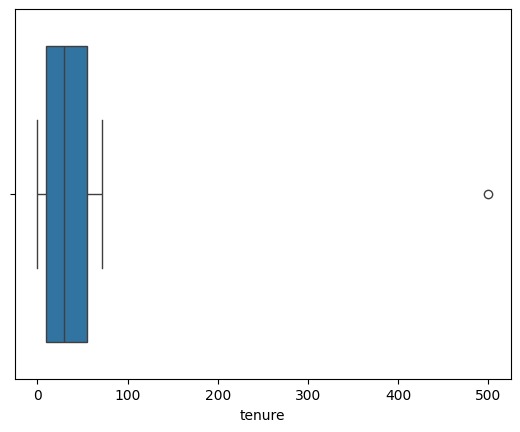

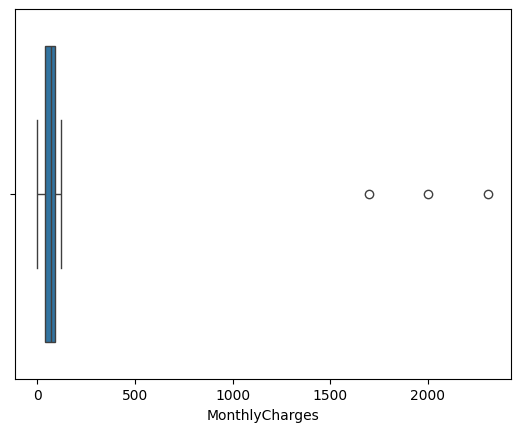

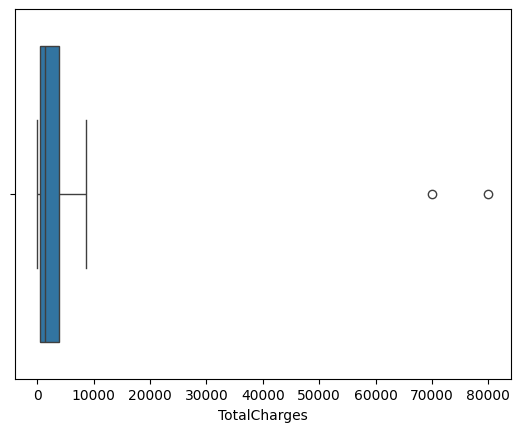

In [ ]:
# Mendeteksi Adanya Outlier Menggunakan Boxplot

print('\nPersebaran data sebelum ditangani Outlier: ')
print(df[['tenure','MonthlyCharges','TotalCharges']].describe())

# Creating Box Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Misal untuk kolom tenure
plt.figure()
sns.boxplot(x=df['tenure'])
plt.show()
# dan seterusnya untuk kedua kolom yang tersisa secara berurut
plt.figure()
sns.boxplot(x=df['MonthlyCharges'])
plt.show()
plt.figure()
sns.boxplot(x=df['TotalCharges'])
plt.show()

In [ ]:
# Mengatasi Outlier

# Handling with IQR
# Definisikan kolom-kolom numerik yang akan diperiksa outlier
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

# Hitung Q1, Q3, IQR, maximum, dan minimum hanya untuk kolom-kolom ini
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1
maximum  = Q3 + (1.5*IQR)
print('Nilai Maximum dari masing-masing Variable adalah: ')
print(maximum)
minimum = Q1 - (1.5*IQR)
print('\nNilai Minimum dari masing-masing Variable adalah: ')
print(minimum)

# Buat salinan DataFrame untuk menyimpan hasil penanganan outlier
df_load = df.copy()

# Terapkan penanganan outlier langsung ke kolom-kolom yang relevan di df_load
# Dengan melakukan operasi pada df_load[numeric_cols], kita memastikan operan selaras.
df_load[numeric_cols] = df_load[numeric_cols].mask(df_load[numeric_cols] > maximum, maximum, axis=1)
df_load[numeric_cols] = df_load[numeric_cols].mask(df_load[numeric_cols] < minimum, minimum, axis=1)

print('\nPersebaran data setelah ditangani Outlier: ')
print(df_load[['tenure','MonthlyCharges','TotalCharges']].describe())

Nilai Maximum dari masing-masing Variable adalah: 
tenure             124.00000
MonthlyCharges     169.93125
TotalCharges      8889.13125
dtype: float64

Nilai Minimum dari masing-masing Variable adalah: 
tenure             -60.00000
MonthlyCharges     -43.61875
TotalCharges     -4682.31875
dtype: float64

Persebaran data setelah ditangani Outlier: 
            tenure  MonthlyCharges  TotalCharges
count  6950.000000     6950.000000   6950.000000
mean     32.423165       64.992201   2286.058750
std      24.581073       30.032040   2265.702553
min       0.000000        0.000000     19.000000
25%       9.000000       36.462500    406.975000
50%      29.000000       70.450000   1400.850000
75%      55.000000       89.850000   3799.837500
max     124.000000      169.931250   8889.131250


In [ ]:
# Ver 2

# Handling with IQR
Q1 = (df[['tenure','MonthlyCharges','TotalCharges']]).quantile(0.25)
Q3 = (df[['tenure','MonthlyCharges','TotalCharges']]).quantile(0.75)

IQR = Q3 - Q1
maximum  = Q3 + (1.5*IQR)
print('Nilai Maximum dari masing-masing Variable adalah: ')
print(maximum)
minimum = Q1 - (1.5*IQR)
print('\nNilai Minimum dari masing-masing Variable adalah: ')
print(minimum)

# Buat salinan DataFrame untuk menyimpan hasil penanganan outlier
df_load = df.copy()

more_than     = (df_load > maximum)
lower_than    = (df_load < minimum)
df_load       = df.mask(more_than, maximum, axis=1)
df_load       = df.mask(lower_than, minimum, axis=1)

print('\nPersebaran data setelah ditangani Outlier: ')
print(df_load[['tenure','MonthlyCharges','TotalCharges']].describe())

...
Error ValueError: Operands are not aligned yang terjadi di cell J8AAjsAmQS_A disebabkan oleh ketidaksesuaian dimensi saat membandingkan data.

Dalam kode tersebut:

Variabel maximum dan minimum hanya dihitung untuk tiga kolom numerik: 'tenure', 'MonthlyCharges', dan 'TotalCharges'.
Namun, ketika Anda mencoba melakukan perbandingan more_than = (df_load > maximum) dan lower_than = (df_load < minimum), Anda mencoba membandingkan seluruh DataFrame df_load (yang memiliki semua 22 kolom) dengan maximum atau minimum (yang hanya memiliki 3 kolom). Pandas tidak dapat menyelaraskan kolom-kolom yang tidak cocok antara kedua 'operand' ini, sehingga muncullah error tersebut.
Perbaikan yang sudah dilakukan di cell DP1LTV7MMJ0r mengatasi ini dengan secara eksplisit menerapkan operasi mask hanya pada kolom-kolom numerik yang relevan di df_load (df_load[numeric_cols] = df_load[numeric_cols].mask(...)), sehingga memastikan bahwa perbandingan dan penggantian nilai dilakukan hanya pada bagian DataFrame yang selaras dengan maximum dan minimum.
...

SyntaxError: invalid syntax (ipython-input-1512825642.py, line 27)

. . .
Gunakan fungsi quantile() untuk melihat quantile tertentu, dan gunakan mask() untuk me-replace nilai. Tentukan:
Nilai minimum dan maximum data di tolerir
Ubah nilai yang di luar range minimum & maximum ke dalam nilai minimum dan maximum
. . .

...
Kesimpulan:
Dari ketiga boxplot dengan variable 'tenure','MonthlyCharges' & 'TotalCharges' terlihat jelas bahwasannya ada outlier. Hal ini bisa di identifikasi dari adanya titik-titik yang berada jauh dari gambar boxplot-nya. Kemudian kalau kita liat persebaran datanya dari kolom max nya juga ada nilai yang sangat tinggi sekali.

Kemudian nilai outlier tersebut ditangani dengan cara merubah nilainya ke nilai maximum & minimum dari interquartile range (IQR). Setelah di tangani outlier-nya, dan dilihat perseberan datanya, terlihat sudah tidak ada lagi nilai yang outlier.
...

In [ ]:
# Mendeteksi Nilai yang tidak Standar

# Identifikasi kolom kategorik (umumnya bertipe 'object')
categorical_cols = df_load.select_dtypes(include='object').columns

print('Mendeteksi nilai tidak standar pada kolom kategorik:')
for col in categorical_cols:
    print(f'\n--- Kolom: {col} ---')
    print(df_load[col].value_counts())
    print('--------------------')

Mendeteksi nilai tidak standar pada kolom kategorik:

--- Kolom: customerID ---
customerID
45512902699    1
45759018157    1
45557574145    1
45366876421    1
45779536532    1
              ..
45976378914    1
45638801276    1
45789265516    1
45671351533    1
45145219511    1
Name: count, Length: 6950, dtype: int64
--------------------

--- Kolom: gender ---
gender
Male         3499
Female       3431
Wanita         14
Laki-Laki       6
Name: count, dtype: int64
--------------------

--- Kolom: Partner ---
Partner
No     3591
Yes    3359
Name: count, dtype: int64
--------------------

--- Kolom: Dependents ---
Dependents
No     4870
Yes    2060
Iya      20
Name: count, dtype: int64
--------------------

--- Kolom: PhoneService ---
PhoneService
Yes    6281
No      669
Name: count, dtype: int64
--------------------

--- Kolom: MultipleLines ---
MultipleLines
No                  3346
Yes                 2935
No phone service     669
Name: count, dtype: int64
--------------------

--- Kolo

In [ ]:
# Ver 2

#Loop untuk mendeteksi nilai tidak standar pada kolom kategorik
for col_name in list(['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']):
    print('\nUnique Values Count Before Standardized Variable', col_name)
    print(df_load[col_name].value_counts())


Unique Values Count Before Standardized Variable gender
gender
Male         3499
Female       3431
Wanita         14
Laki-Laki       6
Name: count, dtype: int64

Unique Values Count Before Standardized Variable SeniorCitizen
SeniorCitizen
0    5822
1    1128
Name: count, dtype: int64

Unique Values Count Before Standardized Variable Partner
Partner
No     3591
Yes    3359
Name: count, dtype: int64

Unique Values Count Before Standardized Variable Dependents
Dependents
No     4870
Yes    2060
Iya      20
Name: count, dtype: int64

Unique Values Count Before Standardized Variable PhoneService
PhoneService
Yes    6281
No      669
Name: count, dtype: int64

Unique Values Count Before Standardized Variable MultipleLines
MultipleLines
No                  3346
Yes                 2935
No phone service     669
Name: count, dtype: int64

Unique Values Count Before Standardized Variable InternetService
InternetService
Fiber optic    3057
DSL            2388
No             1505
Name: count, dtyp

...
Mendeteksi apakah ada nilai-nilai dari variable kategorik yang tidak standard. Hal ini biasanya terjadi dikarenakan kesalahan input data. Perbedaan istilah menjadi salah satu faktor yang sering terjadi, untuk itu dibutuhkan standardisasi dari data yang sudah ter-input.

Gunakan fungsi value_counts() untuk melihat jumlah data unique per variable-nya.
...

...
Tentu, mari kita bahas maksudnya dan bagaimana cara mendeteksinya menggunakan value_counts().

Apa itu 'Nilai Kategorik Tidak Standar'?
Dalam dataset, variabel kategorik adalah kolom yang nilainya termasuk dalam satu set kategori atau label yang terbatas (misalnya, 'gender' dengan nilai 'Pria' dan 'Wanita', atau 'PaymentMethod' dengan nilai 'Credit card', 'Bank transfer', dll.).

'Nilai kategorik tidak standar' berarti ada inkonsistensi atau kesalahan dalam penulisan nilai-nilai ini. Contohnya:

Typo/Salah Ketik: 'Pria' vs 'Priia', 'Ya' vs 'Yaa'.
Penggunaan Huruf Besar/Kecil yang Berbeda: 'Male' vs 'male', 'YES' vs 'yes'.
Spasi Ekstra: 'Credit Card' vs 'Credit Card '.
Sinonim/Istilah Berbeda: 'Laki-laki' vs 'Pria', 'Tidak' vs 'No'.
Kesalahan-kesalahan ini membuat sistem menganggap 'Pria' dan 'Priia' sebagai dua kategori yang berbeda, padahal seharusnya sama. Ini akan mengganggu analisis dan model prediktif.

Bagaimana value_counts() Membantu?
Fungsi value_counts() pada kolom pandas adalah alat yang sangat efektif untuk mendeteksi masalah ini. Fungsi ini akan menghitung berapa kali setiap nilai unik muncul dalam kolom tersebut. Dengan melihat outputnya, Anda bisa segera menemukan nilai-nilai yang seharusnya sama tetapi ditulis berbeda.

Contoh: Jika Anda menjalankan df['gender'].value_counts(), dan Anda melihat output seperti:

Pria     1000
Wanita    950
pria        5   <- Ini adalah masalah!
Pria         2  <- Ini juga masalah (spasi ekstra)!
Anda akan tahu bahwa ada nilai 'pria' (huruf kecil) dan 'Pria ' (dengan spasi) yang perlu distandarkan menjadi 'Pria'.

Implementasi Kode:
Sekarang, mari kita gunakan value_counts() untuk mendeteksi nilai-nilai yang tidak standar pada variabel kategorik di DataFrame Anda (df_load). Saya akan menampilkan semua nilai unik dan frekuensinya untuk setiap kolom bertipe 'object' (yang biasanya merupakan kolom kategorik) di cell selanjutnya.
...

In [ ]:
# Menstandarisasi Variable Kategorik

df_load = df_load.replace(['Wanita','Laki-Laki','Churn','Iya'],['Female','Male','Yes','Yes'])

#Loop
for col_name in list(['gender','Dependents','Churn']):
    print('\nUnique Values Count After Standardized Variable',col_name)
    print(df_load[col_name].value_counts())


Unique Values Count After Standardized Variable gender
gender
Male      3505
Female    3445
Name: count, dtype: int64

Unique Values Count After Standardized Variable Dependents
Dependents
No     4870
Yes    2080
Name: count, dtype: int64

Unique Values Count After Standardized Variable Churn
Churn
No     5114
Yes    1836
Name: count, dtype: int64


...
mengeteahui variable mana saja yang ada nilai tidak standard, maka kita standardkan dengan pola terbanyak nya, dengan syarat tanpa mengubah maknanya. Contoh : Iya -> Yes Kemudian liat kembali unique values dari masing-masing variable yang sudah di ubah. Gunakan fungsi replace() untuk menstandardkan nilai.
...

...
Kesimpulan:
amati lebih jauh dari jumlah unique value dari masing-masing variable kategorik, terlihat jelas bahwa ada beberapa variable yang tidak standar. Variable itu adalah:

Gender (Female, Male, Wanita, Laki-Laki), yang bisa di standardkan nilainya menjadi (Female, Male) karena mempunyai makna yang sama.
Dependents (Yes, No, Iya), yang bisa di standardkan nilainya menjadi (Yes, No) karena mempunyai makna yang sama.
Churn (Yes, No, Churn), yang bisa di standardkan nilainya menjadi (Yes, No) karena mempunyai makna yang sama.
Setelah standardkan nilainya, dan amati kembali bentuk datanya, sudah terstandar dengan baik untuk unique value-nya.

## Langkah 6: Menambahkan/Memodifikasi Kolom Baru

1. Membuat kolom baru yang mengelompokan isian berupa Yes, No, No internet service, Churn dan NaN.
2. Memodifikasi nilai isian menjadi 0, 1, 2

In [ ]:
survey_cols = [
  'Partner', 'Dependents', 'PhoneService',
  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
  'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

In [ ]:
object_cols = df.select_dtypes(include='object').columns
print('Kolom dengan tipe data object adalah:')
print(list(object_cols))

Kolom dengan tipe data object adalah:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
df[survey_cols].head()

,Partner,Dependents,...,PaperlessBilling,Churn
0,Yes,No,...,Yes,No
1,No,No,...,No,No
2,No,No,...,Yes,Yes
3,No,No,...,No,No
4,No,No,...,Yes,Yes


In [ ]:
for col in survey_cols:
    print(f'col {col} {df[col].unique()}')

col Partner ['Yes' 'No']
col Dependents ['No' 'Yes' 'Iya']
col PhoneService ['No' 'Yes']
col OnlineSecurity ['No' 'Yes' 'No internet service']
col OnlineBackup ['Yes' 'No' 'No internet service']
col DeviceProtection ['No' 'Yes' 'No internet service']
col TechSupport ['No' 'Yes' 'No internet service']
col StreamingTV ['No' 'Yes' 'No internet service']
col StreamingMovies ['No' 'Yes' 'No internet service']
col PaperlessBilling ['Yes' 'No']
col Churn ['No' 'Yes' 'Churn']


In [ ]:
import numpy as np

# Banyak kolom menggunakan for loop

for col in survey_cols:
    print(col)
    #gunakan fungsi berikut
    df[col] = np.where(
        (df[col]=='Yes') | (df[col]=='Churn'), 0, np.where(
            (df[col]=='No')|(df[col]=='No internet service'), 0, df[col]
        )
    )

Partner
Dependents
PhoneService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
PaperlessBilling
Churn


In [ ]:
for col in survey_cols:
    print(f'col {col} {df[col].unique()}')

col Partner [1 0]
col Dependents [0 1 'Iya']
col PhoneService [0 1]
col OnlineSecurity [0 1]
col OnlineBackup [1 0]
col DeviceProtection [0 1]
col TechSupport [0 1]
col StreamingTV [0 1]
col StreamingMovies [0 1]
col PaperlessBilling [1 0]
col Churn [0 1]


### Menggunakan Metode `map()` untuk Standardisasi

Metode `map()` sangat berguna ketika Anda memiliki pemetaan nilai yang jelas dari kategori string ke nilai numerik (atau nilai lain yang diinginkan). Kita akan membuat kamus (dictionary) yang memetakan 'Yes' ke 1, dan 'No' serta 'No internet service' ke 0. Ini akan diterapkan pada kolom-kolom yang ada di `survey_cols` pada DataFrame `df_load`.

In [ ]:
# Definisikan pemetaan nilai dari string ke integer
# Menambahkan 'Iya': 1 karena 'Iya' seharusnya berarti 'Yes' (1)
value_mapping = {'Yes': 1, 'No': 0, 'No internet service': 0, 'Churn': 0, 'Iya': 1}

# Terapkan pemetaan pada setiap kolom di survey_cols di df_load
for col in survey_cols:
    print(f"Memproses kolom: {col}")
    # Menggunakan fillna(0) sebelum astype(int) untuk menangani kemungkinan NaN
    # jika ada nilai lain yang tidak terduga dan tidak ada dalam value_mapping
    df_load[col] = df_load[col].map(value_mapping).fillna(0).astype(int)

print("\nUnique values dan tipe data setelah standardisasi menggunakan map:")
for col in survey_cols:
    print(f'Kolom {col}: Unique values: {df_load[col].unique()}, Dtype: {df_load[col].dtype}')

Memproses kolom: Partner
Memproses kolom: Dependents
Memproses kolom: PhoneService
Memproses kolom: OnlineSecurity
Memproses kolom: OnlineBackup
Memproses kolom: DeviceProtection
Memproses kolom: TechSupport
Memproses kolom: StreamingTV
Memproses kolom: StreamingMovies
Memproses kolom: PaperlessBilling
Memproses kolom: Churn

Unique values dan tipe data setelah standardisasi menggunakan map:
Kolom Partner: Unique values: [0], Dtype: int64
Kolom Dependents: Unique values: [0 1], Dtype: int64
Kolom PhoneService: Unique values: [0 1], Dtype: int64
Kolom OnlineSecurity: Unique values: [0 1], Dtype: int64
Kolom OnlineBackup: Unique values: [1 0], Dtype: int64
Kolom DeviceProtection: Unique values: [0 1], Dtype: int64
Kolom TechSupport: Unique values: [0 1], Dtype: int64
Kolom StreamingTV: Unique values: [0 1], Dtype: int64
Kolom StreamingMovies: Unique values: [0 1], Dtype: int64
Kolom PaperlessBilling: Unique values: [1 0], Dtype: int64
Kolom Churn: Unique values: [0 1], Dtype: int64


### Menggunakan Metode `isin()` untuk Standardisasi

Metode `isin()` dapat digunakan untuk memeriksa apakah nilai dalam sebuah Series (kolom) ada dalam daftar nilai yang diberikan. Dengan mengombinasikannya dengan `.astype(int)`, kita dapat mengonversi nilai menjadi 1 (jika ada dalam daftar 'Yes') dan 0 (jika tidak ada). Ini adalah cara yang ringkas untuk mencapai hasil yang sama.

Catatan: Jika Anda menjalankan cell ini setelah cell yang menggunakan `map()`, kolom-kolom tersebut sudah berupa integer. Untuk demonstrasi, Anda mungkin perlu me-reset `df_load` ke kondisi sebelum standardisasi numerik ini, atau hanya melihat logikanya.

In [ ]:
# Untuk demonstrasi, kita akan membuat salinan baru dari df_load
# agar tidak terpengaruh oleh eksekusi cell sebelumnya jika Anda menjalankannya secara berurutan.
# Jika Anda ingin menerapkan ini pada df_load yang sudah ada, hilangkan baris ini.
df_load_isin_demo = df_load.copy()

# Definisikan daftar nilai yang harus diubah menjadi 1
# 'isin' biasanya digunakan untuk memeriksa apakah suatu nilai ada dalam daftar.
# Untuk mengonversi 'Yes' dan 'Churn' menjadi 1, dan lainnya menjadi 0,
# kita bisa mendefinisikan nilai 'positif' dan memeriksa keanggotaan.
yes_churn_values = ['Yes']

# Terapkan isin() pada setiap kolom di survey_cols di df_load_isin_demo
for col in survey_cols:
    print(f"Memproses kolom: {col}")
    # Mengubah nilai yang ada di yes_churn_values menjadi 1, dan lainnya menjadi 0
    df_load_isin_demo[col] = df_load_isin_demo[col].isin(yes_churn_values).astype(int)

print("\nUnique values dan tipe data setelah standardisasi menggunakan isin (pada df_load_isin_demo):")
for col in survey_cols:
    print(f'Kolom {col}: Unique values: {df_load_isin_demo[col].unique()}, Dtype: {df_load_isin_demo[col].dtype}')

Memproses kolom: Partner
Memproses kolom: Dependents
Memproses kolom: PhoneService
Memproses kolom: OnlineSecurity
Memproses kolom: OnlineBackup
Memproses kolom: DeviceProtection
Memproses kolom: TechSupport
Memproses kolom: StreamingTV
Memproses kolom: StreamingMovies
Memproses kolom: PaperlessBilling
Memproses kolom: Churn

Unique values dan tipe data setelah standardisasi menggunakan isin (pada df_load_isin_demo):
Kolom Partner: Unique values: [0], Dtype: int64
Kolom Dependents: Unique values: [0 1], Dtype: int64
Kolom PhoneService: Unique values: [0 1], Dtype: int64
Kolom OnlineSecurity: Unique values: [0 1], Dtype: int64
Kolom OnlineBackup: Unique values: [1 0], Dtype: int64
Kolom DeviceProtection: Unique values: [0 1], Dtype: int64
Kolom TechSupport: Unique values: [0 1], Dtype: int64
Kolom StreamingTV: Unique values: [0 1], Dtype: int64
Kolom StreamingMovies: Unique values: [0 1], Dtype: int64
Kolom PaperlessBilling: Unique values: [1 0], Dtype: int64
Kolom Churn: Unique values:

In [ ]:
# Nilai Statistik
df_load[survey_cols].describe(include='all')

,Partner,Dependents,...,PaperlessBilling,Churn
count,6950,6950,...,6950,6950
unique,2,3,...,2,3
top,No,No,...,Yes,No
freq,3591,4870,...,4114,5114


In [ ]:
# Matematika sederhana
df_load[survey_cols].sum(axis=1) #sebelum run dgn map juga isin akan menggabungkan teks Yes/No masing-masing baris karena axis=1

,0
0,2
1,3
2,5
3,3
4,3
...,...
19,5
18,5
17,6
16,1


### 1. Boxplot menggunakan Pandas built-in `.plot()`

Pandas memiliki fungsi plotting bawaan yang merupakan *wrapper* dari Matplotlib, sehingga Anda bisa membuat boxplot langsung dari DataFrame atau Series.

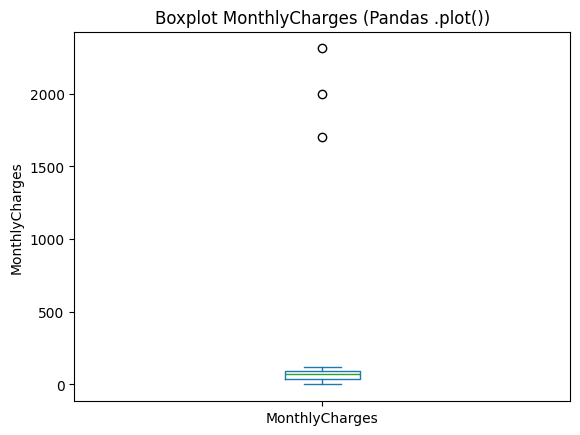

In [ ]:
import matplotlib.pyplot as plt

df['MonthlyCharges'].plot(kind='box', title='Boxplot MonthlyCharges (Pandas .plot())')
plt.ylabel('MonthlyCharges')
plt.show()

### 2. Boxplot menggunakan Seaborn

Seaborn adalah pustaka visualisasi data tingkat tinggi yang dibangun di atas Matplotlib. Ini sangat baik untuk membuat plot statistik yang indah dan informatif.

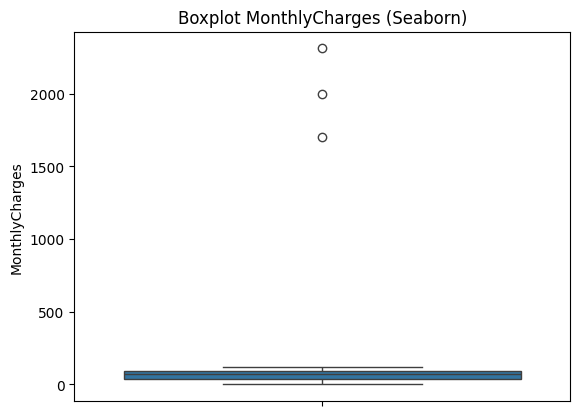

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df['MonthlyCharges'])
plt.title('Boxplot MonthlyCharges (Seaborn)')
plt.ylabel('MonthlyCharges')
plt.show()

### 3. Boxplot menggunakan Matplotlib

Matplotlib adalah pustaka plotting dasar di Python. Anda dapat membuat boxplot dengan kontrol yang lebih granular, meskipun sintaksnya bisa sedikit lebih verbose.

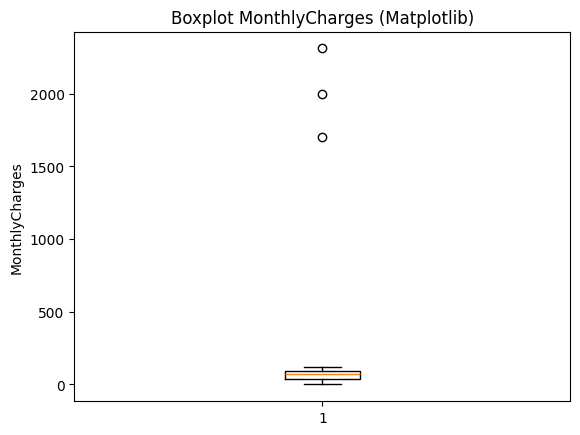

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.boxplot(df['MonthlyCharges'])
ax.set_title('Boxplot MonthlyCharges (Matplotlib)')
ax.set_ylabel('MonthlyCharges')
plt.show()

### 1. Histogram menggunakan Pandas built-in `.plot()`

Pandas menyediakan fungsi `hist()` sebagai *wrapper* dari Matplotlib, memungkinkan Anda membuat histogram langsung dari DataFrame atau Series.

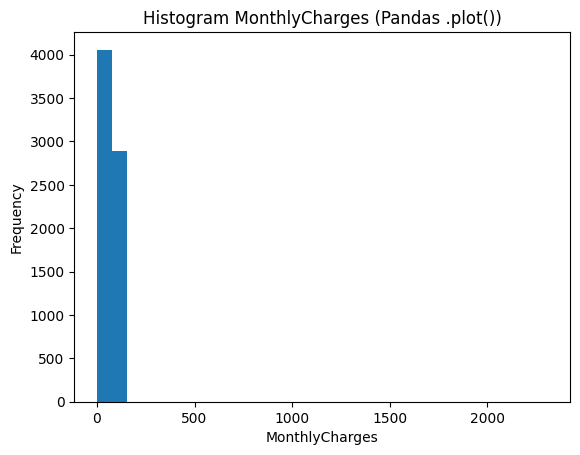

In [ ]:
import matplotlib.pyplot as plt

df_load['MonthlyCharges'].plot(kind='hist', bins=30, title='Histogram MonthlyCharges (Pandas .plot())')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.show()

### 2. Histogram menggunakan Seaborn

Seaborn memiliki fungsi `histplot()` yang lebih kaya fitur dan estetika untuk membuat histogram, seringkali lebih informatif dan menarik secara visual.

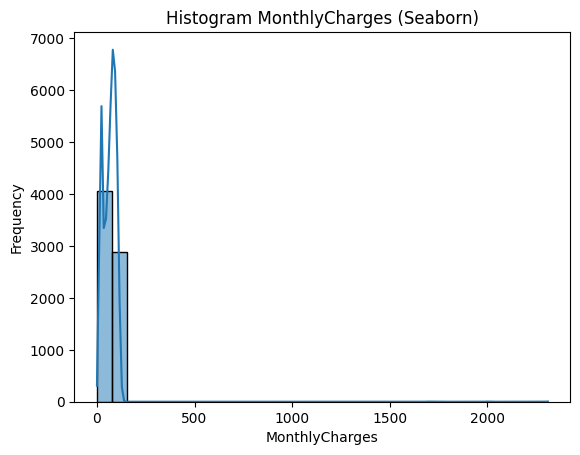

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_load['MonthlyCharges'], bins=30, kde=True)
plt.title('Histogram MonthlyCharges (Seaborn)')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.show()

### 3. Histogram menggunakan Matplotlib

Matplotlib adalah pustaka dasar untuk plotting. Anda dapat membuat histogram dengan fungsi `hist()` untuk kontrol yang lebih granular.

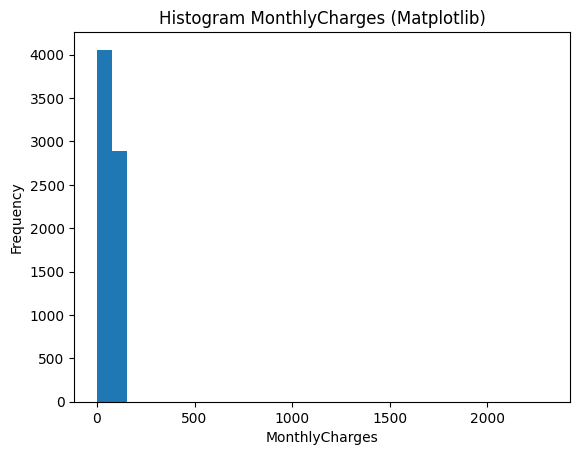

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_load['MonthlyCharges'], bins=30)
plt.title('Histogram MonthlyCharges (Matplotlib)')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.tail(10)

,UpdatedAt,customerID,...,TotalCharges,Churn
24,202006,45632288661,...,2970.30,0
23,202006,45363825122,...,3505.10,0
22,202006,45106601971,...,20.15,1
21,202006,45168014322,...,202.25,0
20,202006,45877978431,...,39.65,1
19,202006,45418334682,...,1862.90,0
18,202006,45419036262,...,528.35,1
17,202006,45995925610,...,7382.25,0
16,202006,45819132957,...,1022.95,0
14,202006,45512902699,...,2686.05,0


In [ ]:
df_load.tail(10)

,UpdatedAt,customerID,...,TotalCharges,Churn
24,202006,45632288661,...,2970.30,0
23,202006,45363825122,...,3505.10,0
22,202006,45106601971,...,20.15,1
21,202006,45168014322,...,202.25,0
20,202006,45877978431,...,39.65,1
19,202006,45418334682,...,1862.90,0
18,202006,45419036262,...,528.35,1
17,202006,45995925610,...,7382.25,0
16,202006,45819132957,...,1022.95,0
14,202006,45512902699,...,2686.05,0
